## Introduction
The following case study focuses on Cyclistic, a bike-share company that seeks to better understand its customers and how they use its services. As junior data analysts, our role is to work with the data provided by the organization to uncover meaningful insights that can support business decision-making.

Through the data analysis process, we will explore user behavior and identify relevant trends that can help the company better understand its customer base. The findings obtained throughout this study will serve as a foundation for future business and marketing decisions, allowing Cyclistic to continue improving its services and strengthening its position in the market.

### About the Company
In 2016, Cyclistic launched a successful bike-share offering. Since then, the program has grown to a fleet of 5,824 bicycles that are geotracked and locked into a network of 692 stations across Chicago. The bikes can be unlocked from one station and returned to any other station in the system anytime.

Until now, Cyclistic’s marketing strategy relied on building general awareness and appealing to broad consumer segments. One approach that helped make these things possible was the flexibility of its pricing plans: single-ride passes, full-day passes, and annual memberships. Customers who purchase single-ride or full-day passes are referred to as casual riders. Customers who purchase annual memberships are Cyclistic members.

Cyclistic’s finance analysts have concluded that annual members are much more profitable than casual riders. Although the pricing flexibility helps Cyclistic attract more customers, Moreno believes that maximizing the number of annual members will be key to future growth. Rather than creating a marketing campaign that targets all-new customers, Moreno believes there is a solid opportunity to convert casual riders into members. She notes that casual riders are already aware of the Cyclistic program and have chosen Cyclistic for their mobility needs.

Moreno has set a clear goal: Design marketing strategies aimed at converting casual riders into annual members. In order to do that, however, the team needs to better understand how annual members and casual riders differ, why casual riders would buy a membership, and how digital media could affect their marketing tactics. Moreno and her team are interested in analyzing the Cyclistic historical bike trip data to identify trends.

## Ask
### Business Tasks
The objective of this analysis is to examine Cyclistic's historical bike trip data in order to understand how annual members and casual riders use the bike-sharing service differently. The analysis will explore key metrics such as ride duration, ride frequency, bike preferences, usage patterns throughout the week, and seasonal trends to identify when and how each customer group uses the service.

By uncovering these behavioral differences, the analysis aims to provide actionable recommendations and marketing strategies that can encourage casual riders to become annual members. Increasing membership conversions can provide Cyclistic with several benefits, including more predictable revenue streams, stronger customer loyalty, improved customer retention, and greater long-term profitability. Ultimately, these insights will help support data-driven decision-making and contribute to the company's continued growth and success.

#### Stakeholders
- Cyclistic: A bike-share program that features more than 5,800 bicycles and 600
docking stations. 
- Lily Moreno: The director of marketing and your manager. Moreno is responsible for
the development of campaigns and initiatives to promote the bike-share program.
- Cyclistic marketing analytics team: A team of data analysts who are responsible for
collecting, analyzing, and reporting data that helps guide Cyclistic marketing strategy.
- Cyclistic executive team: The notoriously detail-oriented executive team will decide
whether to approve the recommended marketing program.


## Prepare
### Data Source
The dataset used for this analysis comes from a public source and contains historical records of Cyclistic bike trips. The data is organized into monthly files, making it easier to review and work with each period individually before combining them into a single dataset.

For this project, data from June 2025 to June 2026 will be analyzed. Using a full year of data allows us to observe user behavior across different seasons and identify patterns that may not be visible when analyzing only a few months.

### Data Organization
Each file contains information related to bike trips, including ride IDs, bike types, start and end dates, station names, and rider type (casual or member). Since all files follow the same structure, they can be combined into a single database, making it possible to perform a more complete analysis and compare behavior throughout the year.

### Data Limitations
Although the dataset provides a large amount of useful information, there are some limitations that should be considered:
- The dataset does not include demographic information such as age, gender, occupation, or income level.
- The data allows us to see how users behave, but it does not explain the reasons behind their decisions.
- Factors such as weather conditions, holidays, local events, or other external situations may influence bike usage but are not included in the dataset.

### Data Privacy
The dataset is publicly available and does not contain personal information that could identify individual users. This allows the analysis to be conducted while maintaining user privacy and data security.

Aproximadamente el 21% de los registros no contenían información sobre la estación de origen o destino. Estos registros fueron conservados debido a que seguían siendo válidos para los análisis temporales y de comportamiento de los usuarios. Sin embargo, fueron excluidos de los análisis relacionados con estaciones.

For this analysis, I decided to use SQL to manipulate and analyze the data. Initially, I planned to work with Excel; however, after reviewing the datasets, I noticed that the amount of data was too large, making it difficult to work with efficiently.

For this reason, I chose SQL, since it allows large amounts of data to be handled more easily and makes tasks such as combining datasets, filtering records, performing calculations, and grouping data much more efficient.

Once the data had been cleaned and analyzed, Tableau was used to create the visualizations and dashboard that help present the findings in a more understandable way.

First, I reviewed the databases to understand how the data was organized and to become familiar with their structure. Then, I created a table with the same columns and compatible data types to combine all records into a single table, making the data easier to manage and analyze.

In [ ]:
CREATE TABLE cyclistic_trips (
    ride_id TEXT,
    rideable_type TEXT,
    started_at TEXT,
    ended_at TEXT,
    start_station_name TEXT,
    start_station_id TEXT,
    end_station_name TEXT,
    end_station_id TEXT,
    start_lat TEXT,
    start_lng TEXT,
    end_lat TEXT,
    end_lng TEXT,
    member_casual TEXT
);

After that, I imported all the datasets into the previously created table. Combining the records into a single dataset made the data easier to manage, clean, and analyze, while also simplifying the process of running queries and generating insights from the complete set of trip records.

In [ ]:
.import --csv --skip 1 202506-divvy-tripdata.csv cyclistic_trips
.import --csv --skip 1 202507-divvy-tripdata.csv cyclistic_trips
.import --csv --skip 1 202508-divvy-tripdata.csv cyclistic_trips
.import --csv --skip 1 202509-divvy-tripdata.csv cyclistic_trips
.import --csv --skip 1 202510-divvy-tripdata.csv cyclistic_trips
.import --csv --skip 1 202511-divvy-tripdata.csv cyclistic_trips
.import --csv --skip 1 202512-divvy-tripdata.csv cyclistic_trips
.import --csv --skip 1 202601-divvy-tripdata.csv cyclistic_trips
.import --csv --skip 1 202602-divvy-tripdata.csv cyclistic_trips
.import --csv --skip 1 202603-divvy-tripdata.csv cyclistic_trips
.import --csv --skip 1 202604-divvy-tripdata.csv cyclistic_trips
.import --csv --skip 1 202605-divvy-tripdata.csv cyclistic_trips

Throughout the import process, I frequently checked the row count after each dataset was added to confirm that the records were being imported correctly. This validation step helped ensure data integrity and provided confidence that all datasets were successfully combined into a single table.

## Process
### Data Inspection

After importing and consolidating the monthly datasets into a single table, an initial inspection was performed to verify the integrity of the data and identify potential quality issues.

To confirm that all records were imported successfully, the total number of rows was checked:

In [ ]:
SELECT COUNT(*) FROM cyclistic_trips;

The dataset contained approximately 5.67 million records.

### Missing Values
The dataset was reviewed to identify records containing missing values.

In [ ]:
SELECT
    COUNT(*) - COUNT("ride_id") AS "ride_id_nulls",
    COUNT(*) - COUNT("started_at") AS "started_at_nulls",
    COUNT(*) - COUNT("ended_at") AS "ended_at_nulls",
    COUNT(*) - COUNT("member_casual") AS "member_casual_nulls"
FROM "cyclistic_trips";

The results showed that the dataset contained a single corrupted record with missing values. Since the record lacked essential information required for analysis, it was removed from the dataset

### Duplicate Records
To ensure that each trip was represented only once, the number of total rows was compared with the number of unique ride IDs.

In [ ]:
SELECT
    COUNT(*) AS "total_rows",
    COUNT(DISTINCT "ride_id") AS "unique_rides"
FROM "cyclistic_trips";

The comparison revealed 35 duplicate records. These duplicates were investigated further and confirmed to be exact copies, making them suitable for removal.

### Creating a Clean Dataset
After identifying duplicate records, a cleaned version of the dataset was created using only unique rows.

In [ ]:
CREATE TABLE cyclistic_trips_clean AS
SELECT DISTINCT *
FROM cyclistic_trips;

This step produced a new table containing only unique records and ensured that duplicate trips would not influence the analysis.

### Ride Duration Validation
Trip durations were examined to identify unusual values and verify that ride lengths were reasonable for analysis.

In [ ]:
SELECT
    MIN((julianday("ended_at") - julianday("started_at")) * 24 * 60) AS min_minutes,
    AVG((julianday("ended_at") - julianday("started_at")) * 24 * 60) AS avg_minutes,
    MAX((julianday("ended_at") - julianday("started_at")) * 24 * 60) AS max_minutes
FROM cyclistic_trips_clean;

The minimum, average, and maximum trip durations were reviewed to detect potential anomalies. Most values appeared reasonable and consistent with expected bicycle trip durations.

### Investigation of Negative Durations
Records where the trip end time appeared earlier than the start time were identified and investigated separately.

In [ ]:
SELECT COUNT(*)
FROM cyclistic_trips_clean
WHERE ended_at <= started_at;

A total of 29 rides met this condition. After reviewing the affected records, all were found to occur on November 2, 2025, during the transition from daylight saving time to standard time in the United States. Since these records likely represent legitimate trips affected by the clock change, they were retained in the dataset.

## Analyze
### Ride Frequency and Average Duration by User Type
To compare usage patterns between annual members and casual riders, the total number of trips and average ride duration were calculated for each user group.

In [ ]:
SELECT
    member_casual,
    COUNT(*) AS total_trips,
    ROUND(AVG((julianday(ended_at) - julianday(started_at)) * 24 * 60), 2) AS avg_ride_minutes
FROM cyclistic_trips_clean
GROUP BY member_casual;

The results showed that members generated the majority of rides, while casual riders tended to take longer trips on average. This suggests that members primarily use Cyclistic bikes for transportation and commuting, whereas casual riders are more likely to use them for leisure and recreational purposes.

### Rides by Day of the Week
Trip counts were analyzed by day of the week to identify differences in riding behavior between members and casual riders.

In [ ]:
SELECT
    strftime('%w', started_at) AS weekday,
    member_casual,
    COUNT(*) AS "total_trips"
FROM cyclistic_trips_clean
GROUP BY weekday, member_casual;

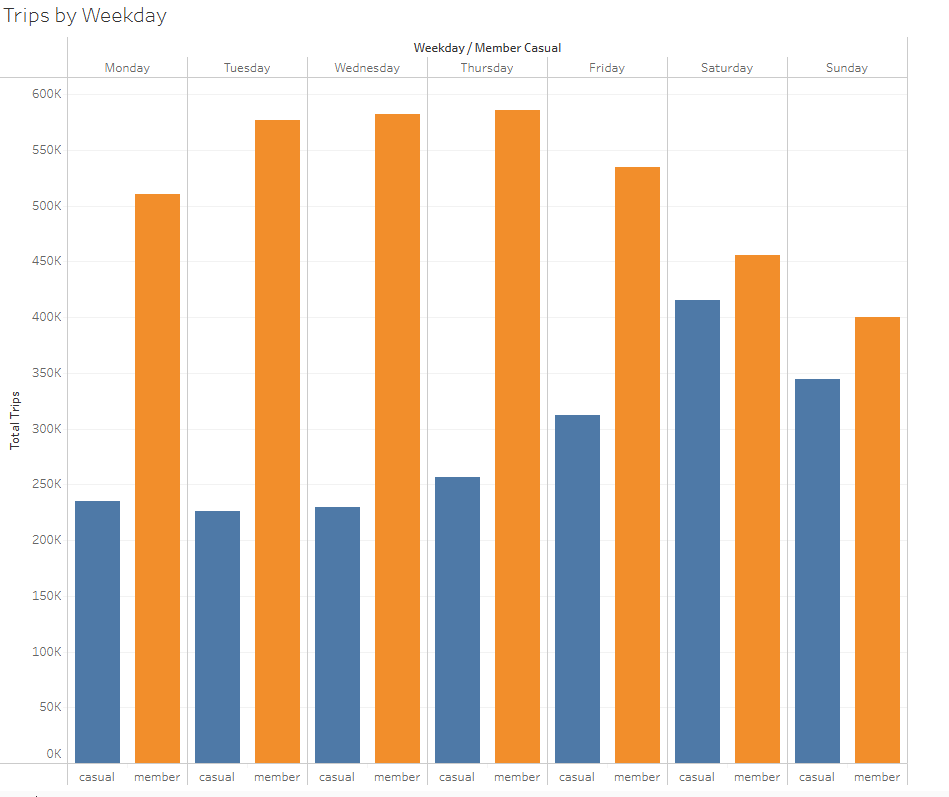

The analysis revealed that casual riders were most active during weekends, while members maintained higher activity levels throughout the workweek. This pattern further supports the idea that members use the service primarily for commuting, whereas casual riders use it more frequently for recreational activities.

### Rides by Hour
To understand how ride demand varies throughout the day, trips were analyzed by the hour in which they started. This helps identify peak usage times and differences in daily routines between casual riders and annual members.

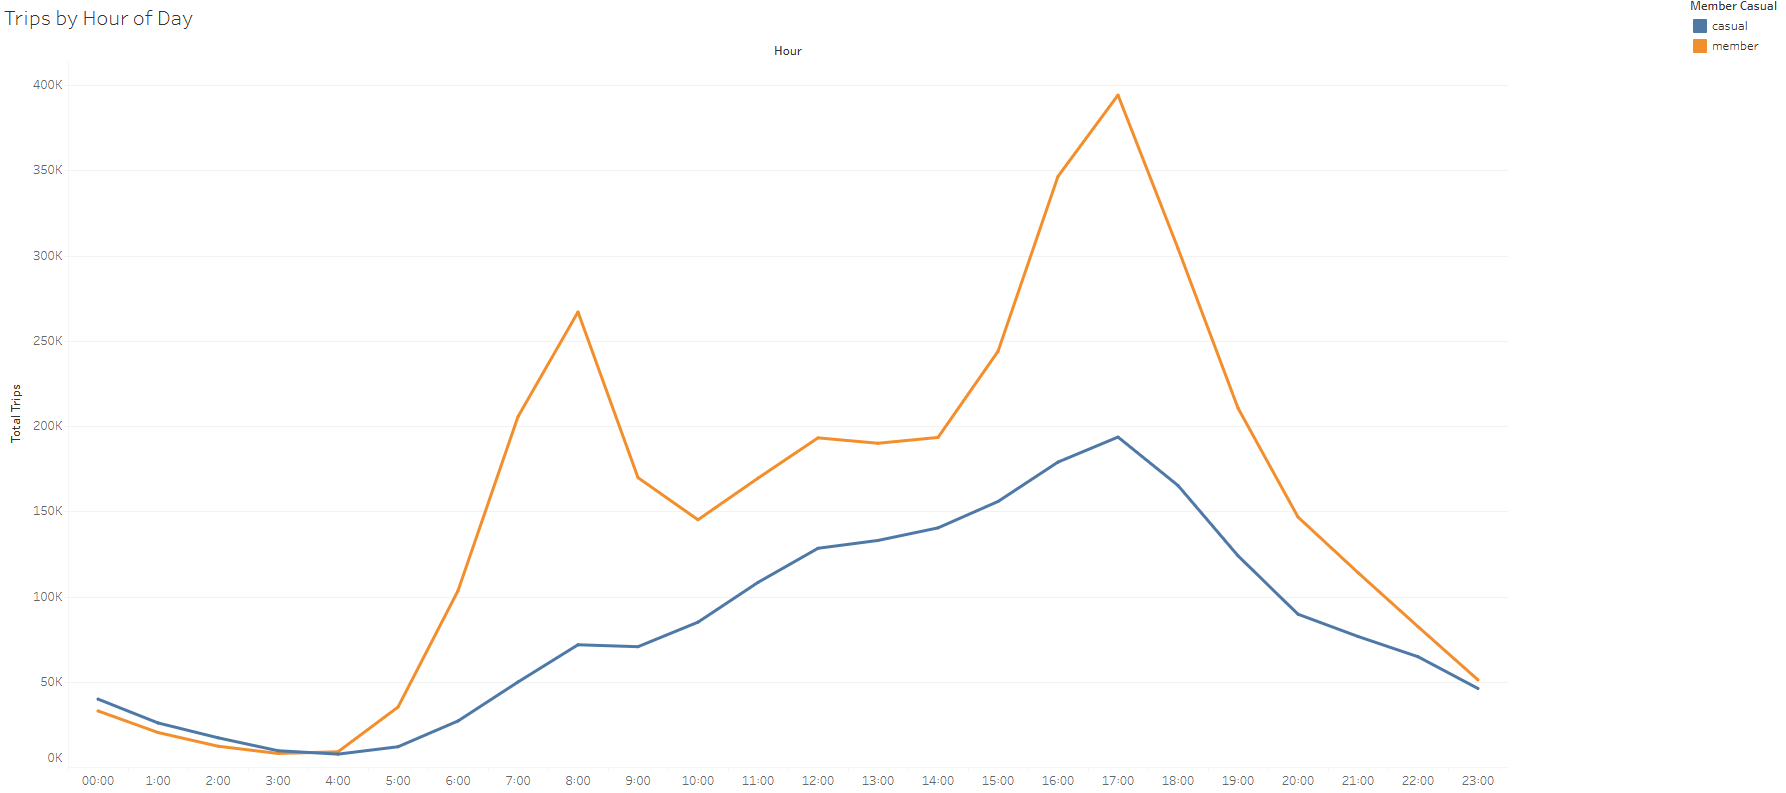

Casual riders tend to show higher activity during the afternoon and evening hours, suggesting more recreational or flexible usage patterns.
In contrast, annual members concentrate their trips during early morning and late afternoon hours, which is consistent with commuting behavior to and from work or school.
Overall, members display a more structured and routine-based usage pattern, while casual riders show more variability throughout the day.

### Rides by Month
To analyze seasonal patterns in Cyclistic usage, trips were grouped by month to identify trends in ride volume throughout the year.

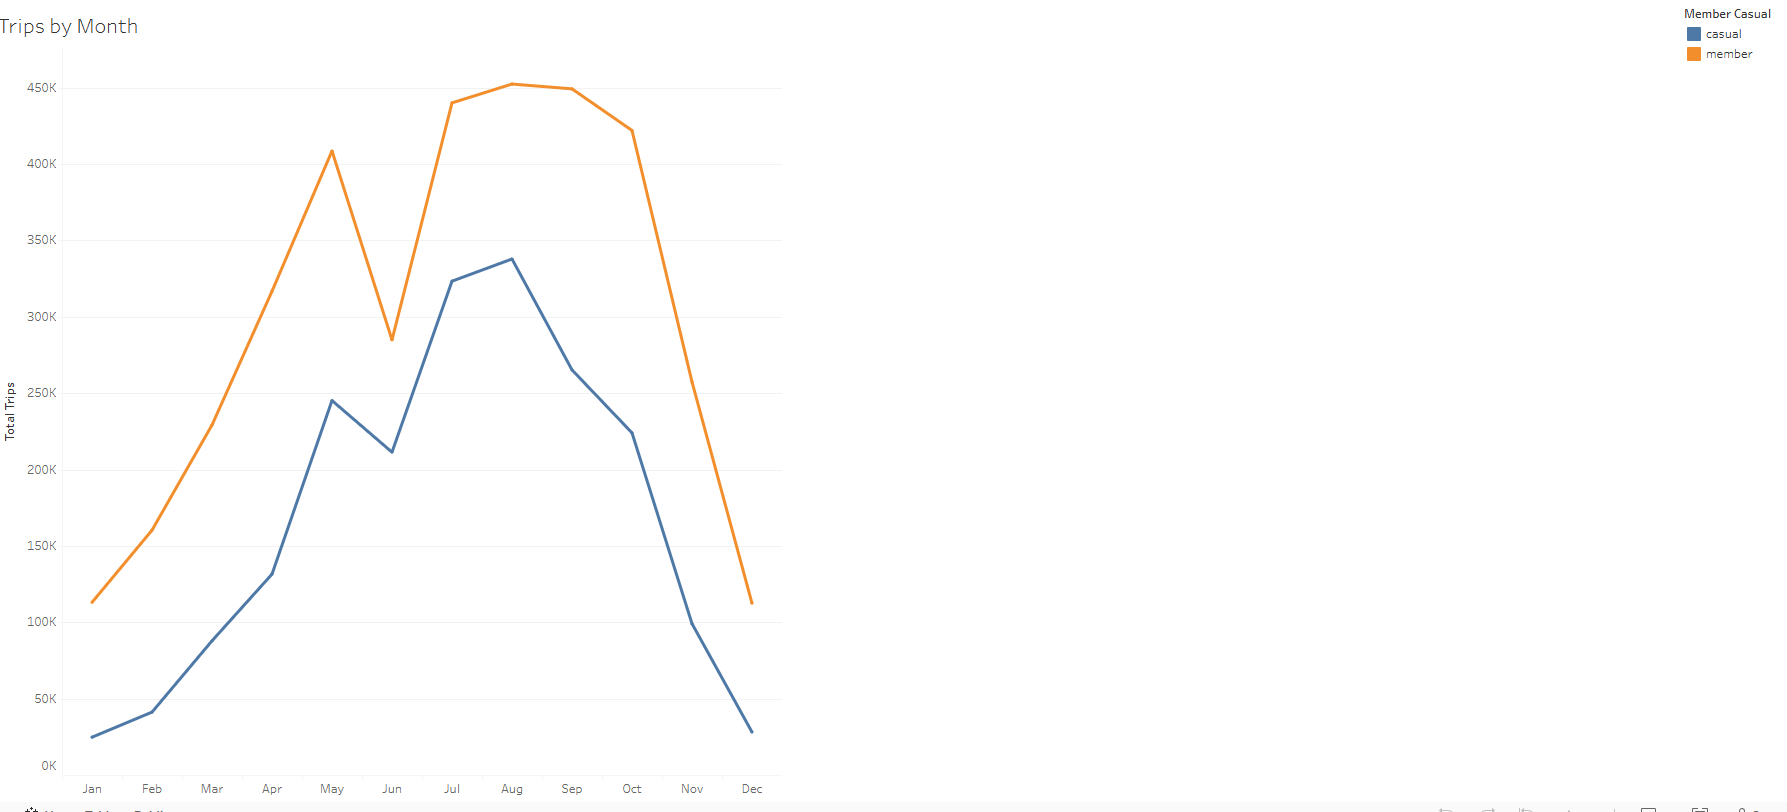

Casual riders show noticeable increases in ride activity during warmer months, particularly in summer and vacation periods. This suggests a stronger connection to leisure and tourism-related usage.
In contrast, annual members maintain a more stable level of activity throughout the year, with less variation between months. This pattern reinforces the idea of consistent, routine usage.
Overall, seasonal trends are more pronounced among casual riders, while members exhibit steady commuting behavior regardless of the time of year.
Weather and vacation periods appear to have a stronger influence on casual riders than on annual members.

### Popular Stations
To identify key usage locations, the most frequently used start stations were analyzed. This helps understand where riders begin their trips and reveals differences in spatial behavior between casual riders and annual members.

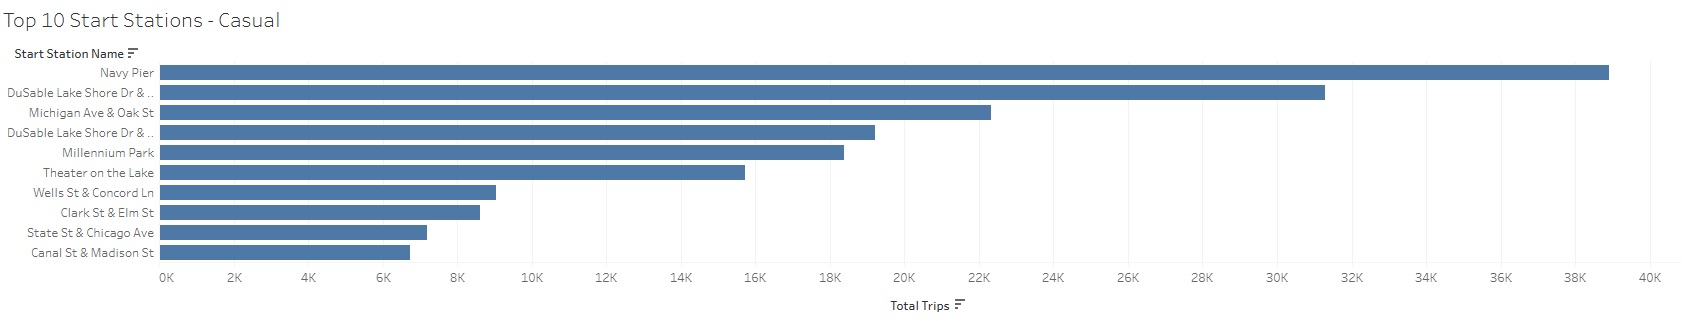
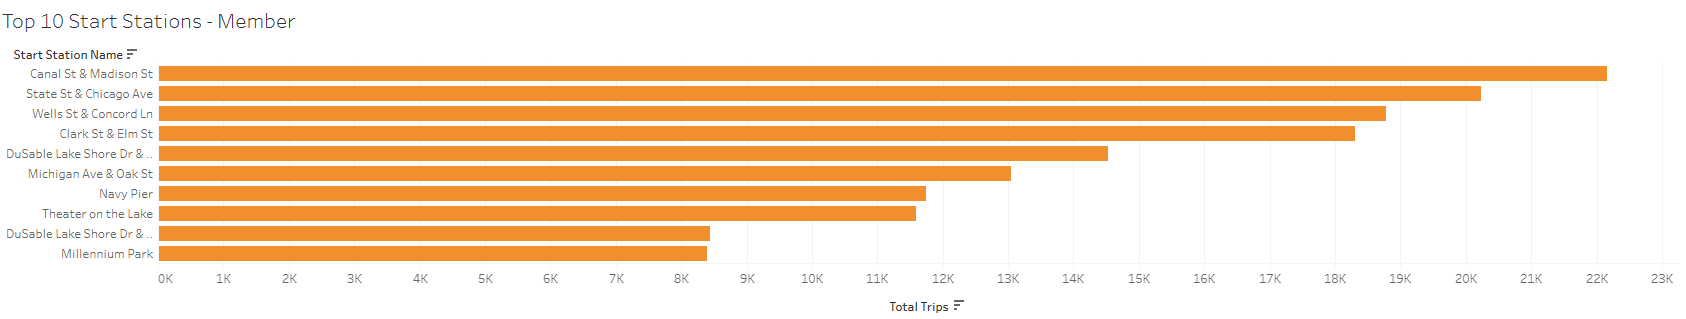

Casual riders tend to concentrate their trips in specific high-traffic or recreational stations, suggesting usage linked to tourism, leisure activities, or popular urban areas.
Annual members, on the other hand, show a more distributed pattern across multiple stations, which is consistent with daily commuting behavior rather than localized leisure use.
This difference indicates that casual riders are more dependent on destination-based hotspots, while members use the system more consistently across the city network.

## Share
In this phase, the analysis results were visualized using Tableau to communicate the main differences between annual members and casual riders.

https://public.tableau.com/views/Cyclistic_17816742028100/CyclisticUserBehaviorAnalysis?:language=es-ES&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

### Key Findings
- Members ride more frequently than casual riders
Annual members generated 3,646,524 trips, while casual riders generated 2,019,570 trips. This indicates that members use Cyclistic bikes more consistently throughout the year.

- Casual riders take longer trips
The average ride duration for casual riders was 22.22 minutes, compared to 12.46 minutes for members. This suggests that casual riders are more likely to use bikes for leisure or recreational purposes rather than transportation.

- Riding behavior differs by day of the week
Casual riders show higher activity during weekends, while members ride more frequently during weekdays. This pattern supports the idea that members use the service for commuting, whereas casual riders use it more for leisure activities.

- Riding behavior differs throughout the day
Members tend to ride during morning and afternoon peak hours, consistent with work and school commuting patterns. Casual riders are more active during afternoon and evening hours, indicating more flexible and recreational usage.

- Casual riders are more seasonal
Ride activity among casual riders increases during warmer months and vacation periods. In contrast, members maintain a more stable level of activity throughout the year.

- Popular stations attract a larger share of casual riders
The most frequently used stations by casual riders are concentrated around high-traffic and recreational areas. Members show a more distributed usage pattern across the station network, reflecting everyday transportation needs.

## Act
### Recommendations
Based on the findings from the analysis, the following recommendations could help Cyclistic increase the conversion of casual riders into annual members.

1. Target casual riders during peak riding seasons
Casual rider activity increases significantly during warmer months and vacation periods. Cyclistic should launch seasonal membership campaigns during these peak periods, when casual riders are already highly engaged with the service.

2. Promote memberships at popular stations
Since casual riders tend to concentrate their trips around the most popular stations, Cyclistic could place targeted advertisements, QR codes, and membership offers at these locations to increase visibility and encourage sign-ups.

3. Highlight the value of membership for frequent riders
Many casual riders may not realize how much they spend on individual rides. Cyclistic should emphasize the long-term savings and convenience of annual memberships through personalized marketing campaigns and in-app notifications.

4. Develop weekend-focused membership promotions
Because casual riders are more active on weekends, Cyclistic could create promotions specifically designed for weekend users, such as discounted membership trials or limited-time upgrade offers.

### Final Conclusion
The analysis revealed clear behavioral differences between annual members and casual riders. Members use Cyclistic more frequently and primarily for commuting purposes, while casual riders take longer trips, ride more often on weekends, and show stronger seasonal patterns.

These findings suggest that marketing efforts should focus on casual riders during periods of high engagement, particularly at popular stations and during peak riding seasons. By highlighting the financial and practical benefits of membership, Cyclistic can increase the likelihood of converting casual riders into annual members.